## LOADING THE DATSET AND UNDERSTANDING THE DATA 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('walkrun.csv')

In [3]:
df.head(10)

,date,time,username,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
0,2017-6-30,13:51:15:847724020,viktor,0,0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-2.9296
1,2017-6-30,13:51:16:246945023,viktor,0,0,0.6722,-1.1233,-0.2344,-0.1757,0.0208,0.1269
2,2017-6-30,13:51:16:446233987,viktor,0,0,0.4399,-1.4817,0.0722,-0.9105,0.1063,-2.4367
3,2017-6-30,13:51:16:646117985,viktor,0,0,0.3031,-0.8125,0.0888,0.1199,-0.4099,-2.9336
4,2017-6-30,13:51:16:846738994,viktor,0,0,0.4814,-0.9312,0.0359,0.0527,0.4379,2.4922
5,2017-6-30,13:51:17:46806991,viktor,0,0,0.4044,-0.8056,-0.0956,0.6925,-0.2179,2.5750
6,2017-6-30,13:51:17:246767997,viktor,0,0,0.6320,-1.1290,-0.2982,0.0548,-0.1896,0.4473
7,2017-6-30,13:51:17:446569025,viktor,0,0,0.6670,-1.3503,-0.0880,-0.8094,-0.7938,-1.4348
8,2017-6-30,13:51:17:646152973,viktor,0,0,0.2704,-0.8633,0.1293,-0.4173,-0.1904,-2.6759
9,2017-6-30,13:51:17:846502006,viktor,0,0,0.4690,-1.0740,0.0219,0.0388,1.1491,1.6982


In [4]:
df.shape

(88588, 11)

In [5]:
df.columns

Index(['date', 'time', 'username', 'wrist', 'activity', 'acceleration_x',
       'acceleration_y', 'acceleration_z', 'gyro_x', 'gyro_y', 'gyro_z'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88588 entries, 0 to 88587
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            88588 non-null  object 
 1   time            88588 non-null  object 
 2   username        88588 non-null  object 
 3   wrist           88588 non-null  int64  
 4   activity        88588 non-null  int64  
 5   acceleration_x  88588 non-null  float64
 6   acceleration_y  88588 non-null  float64
 7   acceleration_z  88588 non-null  float64
 8   gyro_x          88588 non-null  float64
 9   gyro_y          88588 non-null  float64
 10  gyro_z          88588 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 7.4+ MB


In [7]:
df.describe()

,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
count,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000
mean,0.522170,0.500801,-0.074811,-0.562585,-0.313956,0.004160,0.037203,0.022327
std,0.499511,0.500002,1.009299,0.658458,0.486815,1.253423,1.198725,1.914423
min,0.000000,0.000000,-5.350500,-3.299000,-3.753800,-4.430600,-7.464700,-9.480000
25%,0.000000,0.000000,-0.381800,-1.033500,-0.376000,-0.920700,-0.644825,-1.345125
50%,1.000000,1.000000,-0.059500,-0.759100,-0.221000,0.018700,0.039300,0.006900
75%,1.000000,1.000000,0.355500,-0.241775,-0.085900,0.888800,0.733700,1.398200
max,1.000000,1.000000,5.603300,2.668000,1.640300,4.874200,8.498000,11.266200


In [8]:
df.dtypes

date               object
time               object
username           object
wrist               int64
activity            int64
acceleration_x    float64
acceleration_y    float64
acceleration_z    float64
gyro_x            float64
gyro_y            float64
gyro_z            float64
dtype: object

In [9]:
df['wrist'].unique()

array([0, 1])

In [10]:
df.isnull().sum()

date              0
time              0
username          0
wrist             0
activity          0
acceleration_x    0
acceleration_y    0
acceleration_z    0
gyro_x            0
gyro_y            0
gyro_z            0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

## EDA

In [12]:
df['activity'].unique()

array([0, 1])

<Axes: xlabel='activity', ylabel='count'>

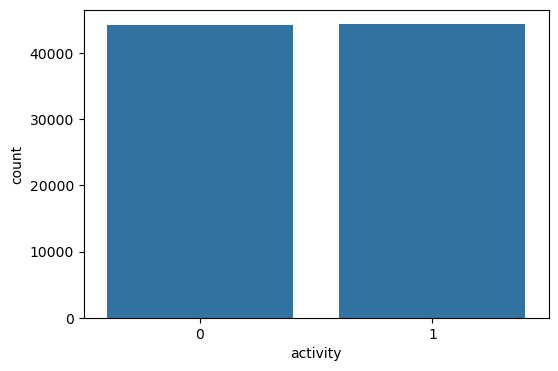

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='activity')

In [14]:
num_cols = [
    'acceleration_x', 'acceleration_y', 'acceleration_z',
    'gyro_x', 'gyro_y', 'gyro_z'
]
print("Numerical Summary (mean, std, min, max, etc.)")
display(df[num_cols].describe().T)
print("\nRange of values for each sensor axis:")
for col in num_cols:
    print(f"{col:15s} → min: {df[col].min():8.3f} | max: {df[col].max():8.3f}")


Numerical Summary (mean, std, min, max, etc.)


,count,mean,std,min,25%,50%,75%,max
acceleration_x,88588.0,-0.074811,1.009299,-5.3505,-0.381800,-0.0595,0.355500,5.6033
acceleration_y,88588.0,-0.562585,0.658458,-3.2990,-1.033500,-0.7591,-0.241775,2.6680
acceleration_z,88588.0,-0.313956,0.486815,-3.7538,-0.376000,-0.2210,-0.085900,1.6403
gyro_x,88588.0,0.004160,1.253423,-4.4306,-0.920700,0.0187,0.888800,4.8742
gyro_y,88588.0,0.037203,1.198725,-7.4647,-0.644825,0.0393,0.733700,8.4980
gyro_z,88588.0,0.022327,1.914423,-9.4800,-1.345125,0.0069,1.398200,11.2662



Range of values for each sensor axis:
acceleration_x  → min:   -5.351 | max:    5.603
acceleration_y  → min:   -3.299 | max:    2.668
acceleration_z  → min:   -3.754 | max:    1.640
gyro_x          → min:   -4.431 | max:    4.874
gyro_y          → min:   -7.465 | max:    8.498
gyro_z          → min:   -9.480 | max:   11.266


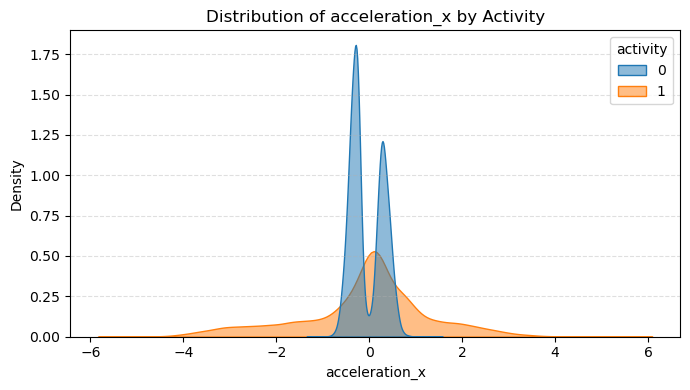

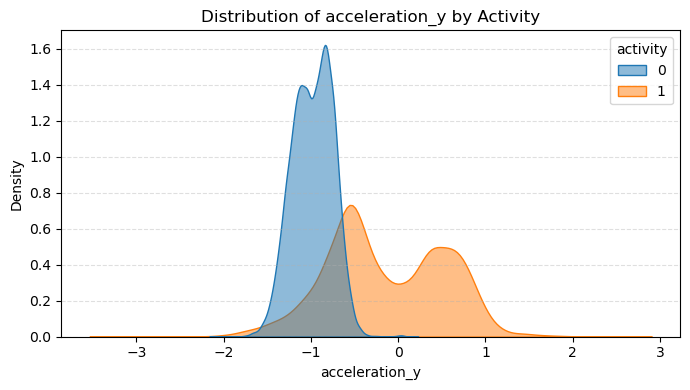

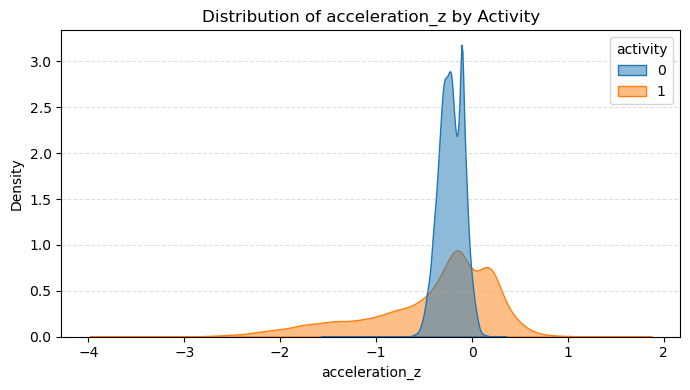

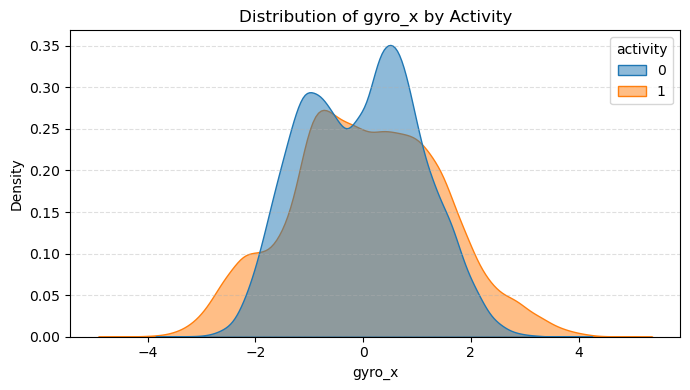

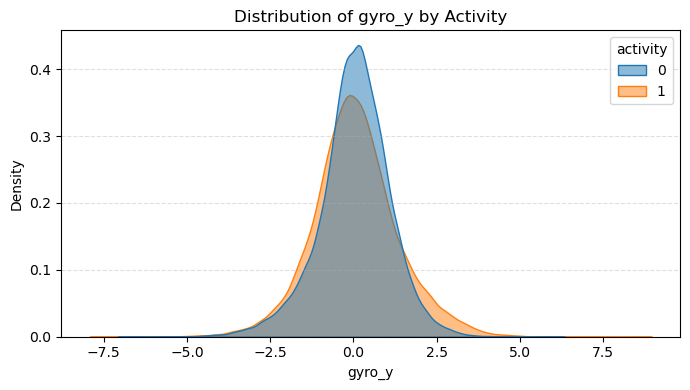

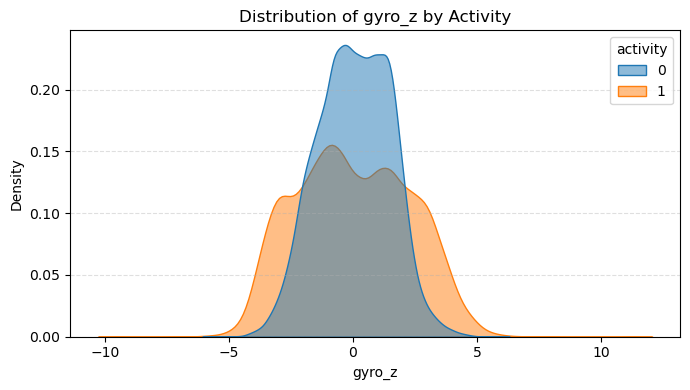

In [15]:
num_cols = [
    'acceleration_x', 'acceleration_y', 'acceleration_z',
    'gyro_x', 'gyro_y', 'gyro_z'
]
if len(df) > 200000:
    df_plot = df.sample(frac=0.05, random_state=42)
    print("Sampled 5% of data for faster plotting.")
else:
    df_plot = df.copy()
for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.kdeplot(data=df_plot, x=col, hue='activity', common_norm=False, fill=True, alpha=0.5)
    plt.title(f"Distribution of {col} by Activity")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


In [16]:
df['acc_magnitude'] = np.sqrt(df['acceleration_x']**2 + 
                              df['acceleration_y']**2 + 
                              df['acceleration_z']**2)

df['gyro_magnitude'] = np.sqrt(df['gyro_x']**2 + 
                               df['gyro_y']**2 + 
                               df['gyro_z']**2)
df[['activity', 'acc_magnitude', 'gyro_magnitude']].head()


,activity,acc_magnitude,gyro_magnitude
0,0,0.825148,2.930374
1,0,1.329887,0.217731
2,0,1.547307,2.603424
3,0,0.871729,2.964524
4,0,1.048889,2.530928


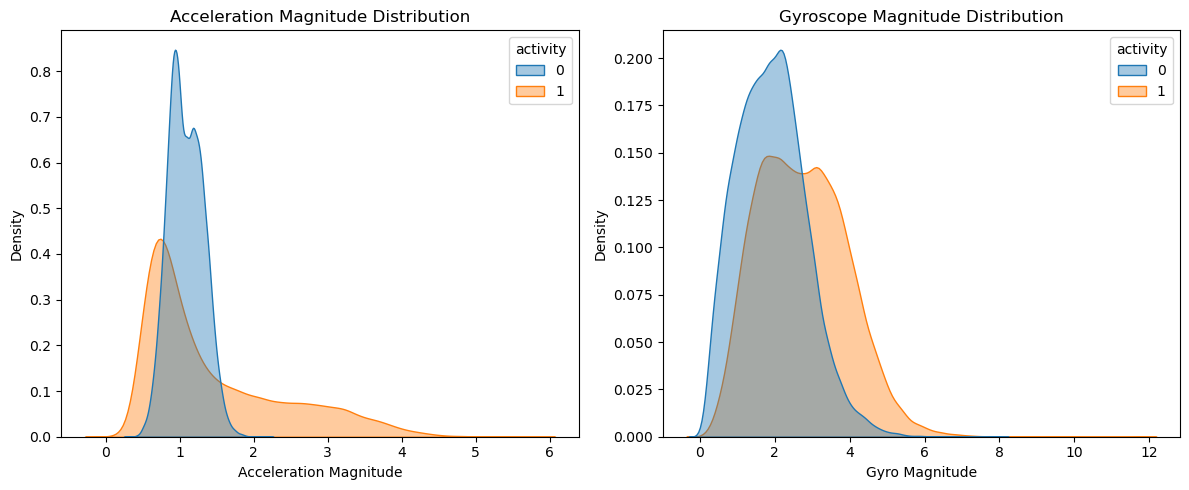

In [17]:
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
sns.kdeplot(data=df, x='acc_magnitude', hue='activity', fill=True, alpha=0.4)
plt.title("Acceleration Magnitude Distribution")
plt.xlabel("Acceleration Magnitude")
plt.ylabel("Density")
plt.subplot(1, 2, 2)
sns.kdeplot(data=df, x='gyro_magnitude', hue='activity', fill=True, alpha=0.4)
plt.title("Gyroscope Magnitude Distribution")
plt.xlabel("Gyro Magnitude")
plt.ylabel("Density")
plt.tight_layout()
plt.show()


In [18]:
numeric_cols = ['acceleration_x', 'acceleration_y', 'acceleration_z',
                'gyro_x', 'gyro_y', 'gyro_z',
                'acc_magnitude', 'gyro_magnitude']
corr_matrix = df[numeric_cols].corr()
corr_matrix

,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z,acc_magnitude,gyro_magnitude
acceleration_x,1.000000,-0.265169,-0.552374,-0.021705,-0.004091,-0.060849,-0.082358,-0.047732
acceleration_y,-0.265169,1.000000,0.106220,0.010549,0.072170,-0.022994,-0.043168,0.106927
acceleration_z,-0.552374,0.106220,1.000000,0.035296,-0.021004,0.049621,-0.547627,-0.235704
gyro_x,-0.021705,0.010549,0.035296,1.000000,0.094011,0.317769,0.029791,0.086099
gyro_y,-0.004091,0.072170,-0.021004,0.094011,1.000000,0.287244,-0.033132,-0.046901
gyro_z,-0.060849,-0.022994,0.049621,0.317769,0.287244,1.000000,-0.006690,0.044511
acc_magnitude,-0.082358,-0.043168,-0.547627,0.029791,-0.033132,-0.006690,1.000000,0.449181
gyro_magnitude,-0.047732,0.106927,-0.235704,0.086099,-0.046901,0.044511,0.449181,1.000000


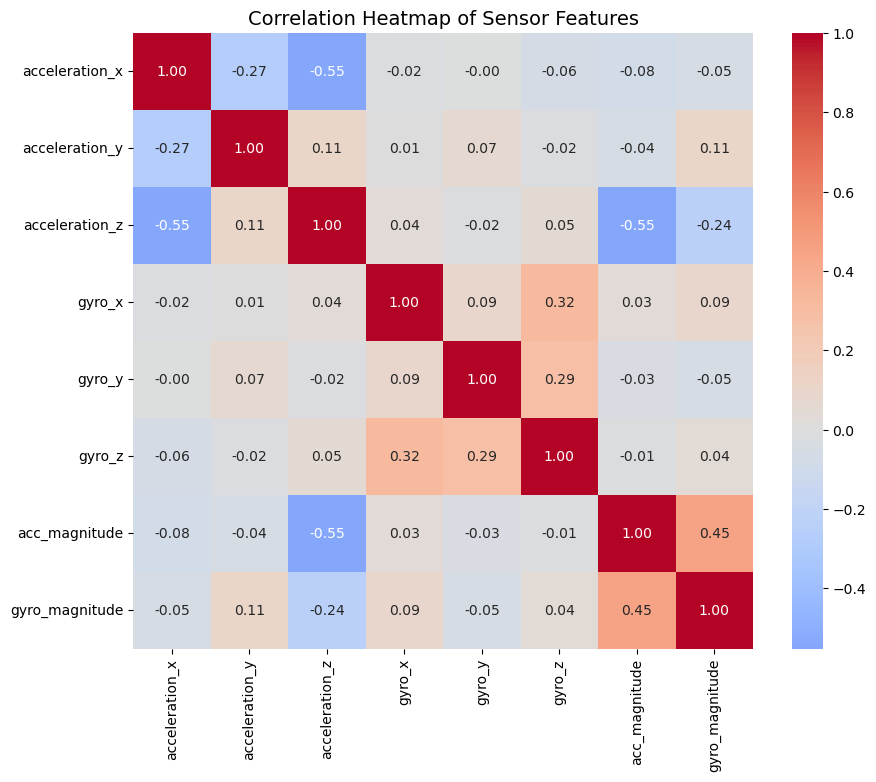

In [19]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Correlation Heatmap of Sensor Features", fontsize=14)
plt.show()


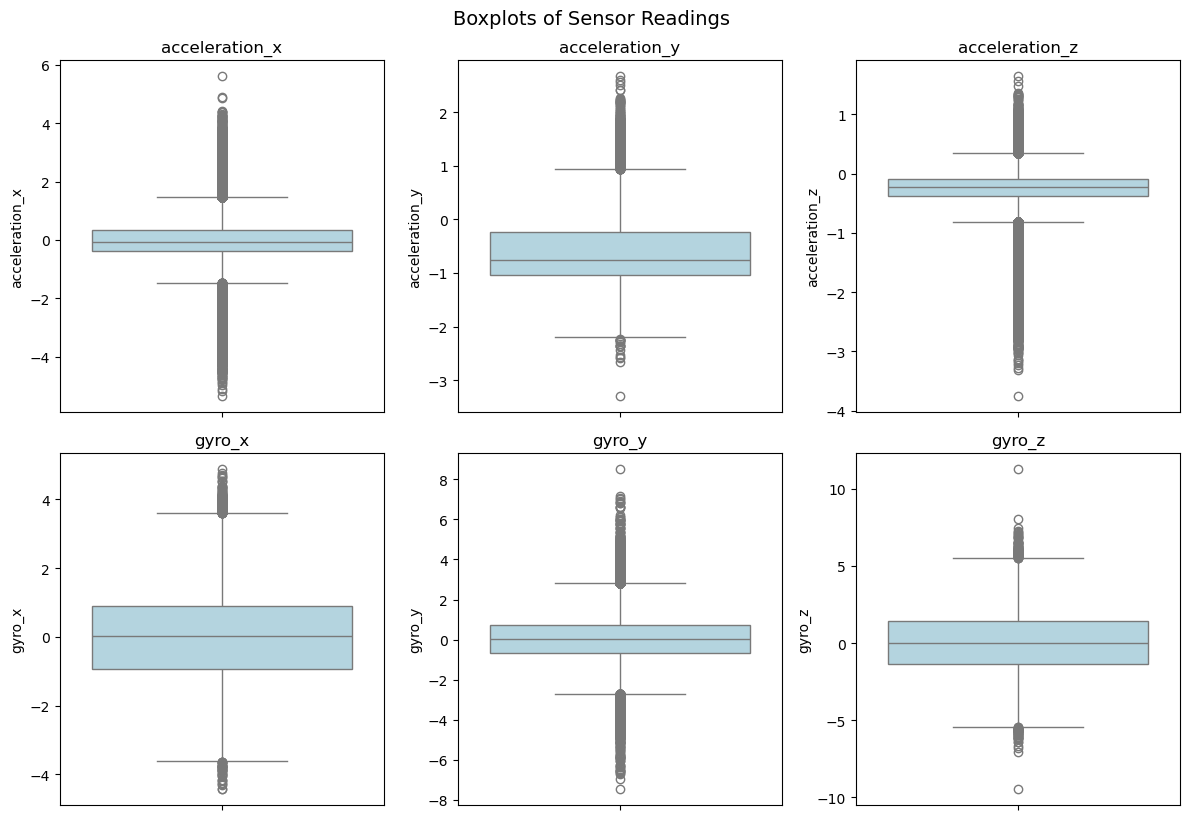

In [20]:
sensor_features = ['acceleration_x', 'acceleration_y', 'acceleration_z',
                   'gyro_x', 'gyro_y', 'gyro_z']
plt.figure(figsize=(12,8))
for i, col in enumerate(sensor_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, y=col, color='lightblue')
    plt.title(col)
    plt.tight_layout()
plt.suptitle("Boxplots of Sensor Readings ", y=1.02, fontsize=14)
plt.show()


### From the analysis, it is observed that acceleration features play a major role in distinguishing between walking and running.
The acceleration readings (especially the magnitude and individual X, Y, Z components) show clear differences in both median values and variance — indicating higher intensity and fluctuation during running.
In contrast, the gyroscope features (gyro_x, gyro_y, gyro_z) show relatively similar distributions for both activities, suggesting that rotational movement is not a strong differentiating factor for this dataset.
Therefore, acceleration-based features provide the most valuable information for classifying whether a person is walking or running.

## Model Creation

In [21]:
X = df[['acceleration_x', 'acceleration_y', 'acceleration_z',
        'gyro_x', 'gyro_y', 'gyro_z',
        'acc_magnitude', 'gyro_magnitude']]
y = df['activity']


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 70870
Testing samples: 17718


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [24]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

X_train_scaled.head()


,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z,acc_magnitude,gyro_magnitude
0,3.430956,-0.537698,-3.112481,0.504780,-2.010645,-1.499858,3.774373,1.270260
1,-1.460232,1.340857,-0.644439,-1.364930,-1.725757,-0.575171,0.606056,0.478501
2,0.354850,1.429326,-0.022135,-0.005337,0.033560,-1.082877,-0.969822,-0.236978
3,-0.820485,2.059723,0.408154,-1.017268,1.083492,-0.263792,-0.087275,-0.365823
4,0.086262,-0.635150,0.295699,1.795480,0.540502,0.638397,-0.375406,0.300085


In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



## Random Forest


In [26]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
print("🔹 Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


🔹 Random Forest Accuracy: 0.9887120442487866
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      8845
           1       0.99      0.99      0.99      8873

    accuracy                           0.99     17718
   macro avg       0.99      0.99      0.99     17718
weighted avg       0.99      0.99      0.99     17718



## SVM

In [27]:
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
print("🔹 SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


🔹 SVM Accuracy: 0.986623772434812
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      8845
           1       0.99      0.98      0.99      8873

    accuracy                           0.99     17718
   macro avg       0.99      0.99      0.99     17718
weighted avg       0.99      0.99      0.99     17718



##  Neural Network

In [28]:
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)
print("🔹 Neural Network Accuracy:", accuracy_score(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))


🔹 Neural Network Accuracy: 0.991590472965346
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      8845
           1       0.99      0.99      0.99      8873

    accuracy                           0.99     17718
   macro avg       0.99      0.99      0.99     17718
weighted avg       0.99      0.99      0.99     17718



C:\Users\dabhi\AppData\Local\Temp\ipykernel_29620\551591514.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results, palette='viridis')


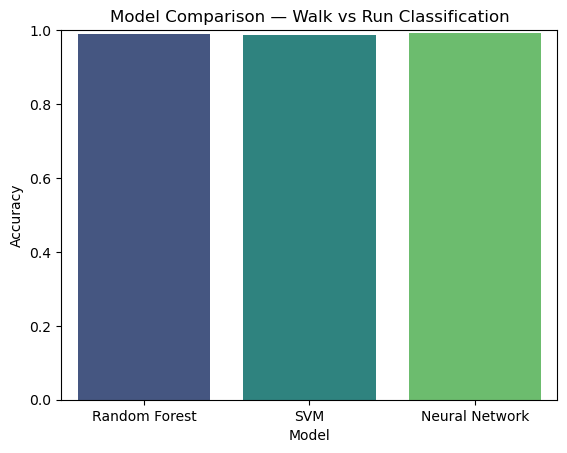

,Model,Accuracy
0,Random Forest,0.988712
1,SVM,0.986624
2,Neural Network,0.991590


In [29]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'SVM', 'Neural Network'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_mlp)
    ]
})

sns.barplot(x='Model', y='Accuracy', data=results, palette='viridis')
plt.title('Model Comparison — Walk vs Run Classification')
plt.ylim(0, 1)
plt.show()
results


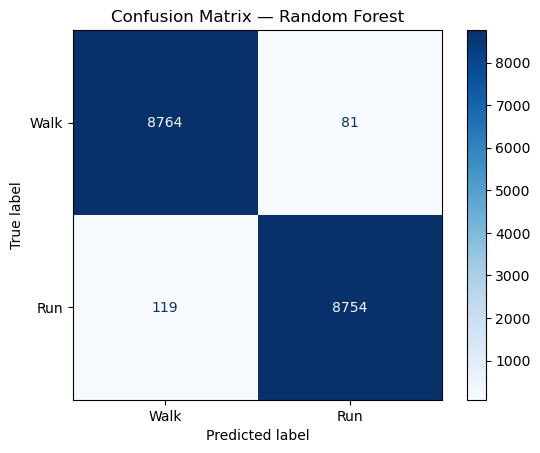

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay
best_model = rf 
y_pred_best = y_pred_rf
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Walk', 'Run'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Random Forest")
plt.show()


## SAMPLE

In [31]:
sample_input = np.array([[0.4480,-1.0231,-0.2715,1.0799,-0.9116,2.5342,1.149413,2.901615]])
sample_scaled = scaler.transform(sample_input)
pred = rf.predict(sample_scaled)
print("Predicted Activity:", pred)

Predicted Activity: [0]


C:\Users\dabhi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\dabhi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


## By observing  all the models, we can see that Random Forest, SVM, and Neural Network achieved the highest accuracies. Based on the precision and recall values, we can conclude that the models performed optimally and were able to classify walking and running effectively.